Dataset Description:

---


The Student Performance Dataset is a dataset designed to examine the factors
influencing academic student performance. The dataset consists of 10,000
student records, with each record containing information about various predictors
and a performance index.
Variables:
Hours Studied: The total number of hours spent studying by each student.
Previous Scores: The scores obtained by students in previous tests.
Extracurricular Activities: Whether the student participates in extracurricular
activities (Yes or No).
Sleep Hours: The average number of hours of sleep the student had per day.
Sample Question Papers Practiced: The number of sample question papers
the student practiced.








# **THE TARGET OF THIS ANALYSIS IS TO UNDERSTAND HOW VARIOUS FACTORS INFLUENCE THE PERFORMANCE INDEX OF A STUDENT.**

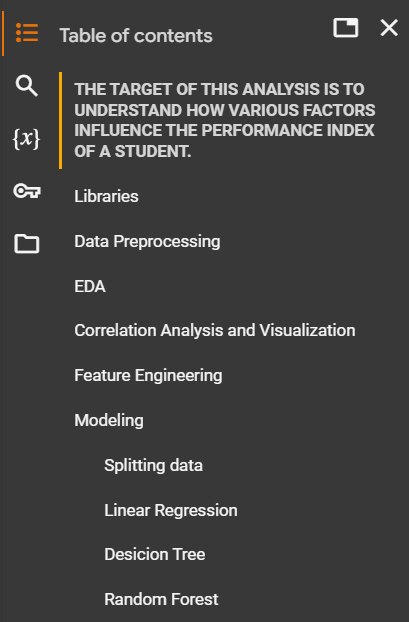

# Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from IPython.display import display
import matplotlib.ticker as ticker
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("Student_Performance - Student_Performance.csv")

#Data Preprocessing

In [ ]:
# printing columns with their unique value count
for i in df.columns:
    print(i , len(df[i].unique()))

Hours Studied 9
Previous Scores 60
Extracurricular Activities 2
Sleep Hours 6
Sample Question Papers Practiced 10
Performance Index 91


In [ ]:
df.columns = df.columns.str.strip() #remove space from columns name to avoid name conflicts

In [ ]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [ ]:
df.isnull().sum() #checking missing values

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
#Checking duplicates
# Count the number of rows that are fully duplicated (including originals)
total_duplicate_rows = df[df.duplicated(keep=False)].shape[0]
print(f'Total duplicate records (including originals and duplicates): {total_duplicate_rows}')

# Count only the rows that are marked as duplicates (excluding the first occurrence)
num_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows (excluding first occurrence): {num_duplicates}')

# Check unique duplicated rows (excluding first occurrence)
unique_duplicates = df[df.duplicated()].shape[0]
print(f'Number of unique duplicated rows: {unique_duplicates}')


Total duplicate records (including originals and duplicates): 253
Number of duplicate rows (excluding first occurrence): 127
Number of unique duplicated rows: 127


In [ ]:
# display all duplicate rows
# Temporarily set pandas to display all rows
pd.set_option('display.max_rows', None)
duplicate_records = df[df.duplicated(keep=False)]  # keep=False to show all occurrences of duplicate rows

# Display the duplicate records
duplicate_records.shape

(253, 6)

In [ ]:
# Reset display option to default
pd.reset_option('display.max_rows')

In [ ]:
print('duplicated records: ' ,df.duplicated().sum())
print()
duplicated=df.duplicated().value_counts()
print(duplicated.head())

duplicated records:  127

False    9873
True      127
Name: count, dtype: int64


In [ ]:
# Detect all duplicate records (including the first occurrence)
duplicate_records = df[df.duplicated(keep=False)]

# Sort the duplicate records based on all columns to ensure duplicates are grouped together
sorted_duplicate_records = duplicate_records.sort_values(by=df.columns.tolist())


print(sorted_duplicate_records.shape)
sorted_duplicate_records.head(8)


(253, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
6975,1,41,No,7,3,12
9966,1,41,No,7,3,12
2225,1,42,Yes,9,7,17
4986,1,42,Yes,9,7,17
2647,1,57,No,8,0,31
8522,1,57,No,8,0,31
3398,1,63,Yes,8,3,37
8184,1,63,Yes,8,3,37


In [ ]:
# Drop all duplicate rows from the original DataFrame in place
df.drop_duplicates(inplace=True)



# Display the shape of the original DataFrame to confirm duplicates were removed
print(f"Shape of the DataFrame after dropping duplicates: {df.shape}")
# Display the first few rows to inspect
df.isnull().sum()

Shape of the DataFrame after dropping duplicates: (9873, 6)


,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


# EDA

In [ ]:
df.info() # get datatypes

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     9873 non-null   int64 
 1   Previous Scores                   9873 non-null   int64 
 2   Extracurricular Activities        9873 non-null   object
 3   Sleep Hours                       9873 non-null   int64 
 4   Sample Question Papers Practiced  9873 non-null   int64 
 5   Performance Index                 9873 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 539.9+ KB


In [ ]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651
std,2.589081,17.325601,1.697683,2.867202,19.208570
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
df[df['Performance Index']<20] .shape

(207, 6)

In [ ]:
df[df['Performance Index']<20] .head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
46,1,43,Yes,7,0,17
78,1,40,Yes,8,8,15
160,2,45,Yes,4,3,18
174,1,43,No,6,4,16
205,3,40,Yes,9,5,18


In [ ]:
df[df['Performance Index']==10]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
332,1,40,No,5,9,10


In [ ]:
df.shape


(9873, 6)

In [ ]:
# unique values for each feature
for i in df.columns :
    print(i)  # Print the column name
    print(df[i].unique())  # Print the unique values
    print()  # Add a blank line (space) between each output


Hours Studied
[7 4 8 5 3 6 2 1 9]

Previous Scores
[99 82 51 52 75 78 73 45 77 89 91 79 47 72 83 54 96 74 85 61 62 84 94 90
 44 70 67 97 59 55 68 63 46 76 43 81 93 98 48 92 64 88 60 87 40 69 80 95
 49 50 53 71 56 58 66 65 57 41 42 86]

Extracurricular Activities
['Yes' 'No']

Sleep Hours
[9 4 7 5 8 6]

Sample Question Papers Practiced
[1 2 5 6 0 8 3 4 9 7]

Performance Index
[ 91  65  45  36  66  61  63  42  69  84  73  27  33  68  43  67  70  30
  71  85  57  35  49  83  74  39  58  47  60  32  64  54  17  53  75  52
  78  38  98  87  41  81  15  88  95  29  21  76  25  34  50  56  82  23
  46  92  77  86  44  94  40 100  31  26  18  51  72  16  28  89  48  37
  62  59  19  79  22  10  90  80  24  20  96  55  97  12  93  14  99  11
  13]



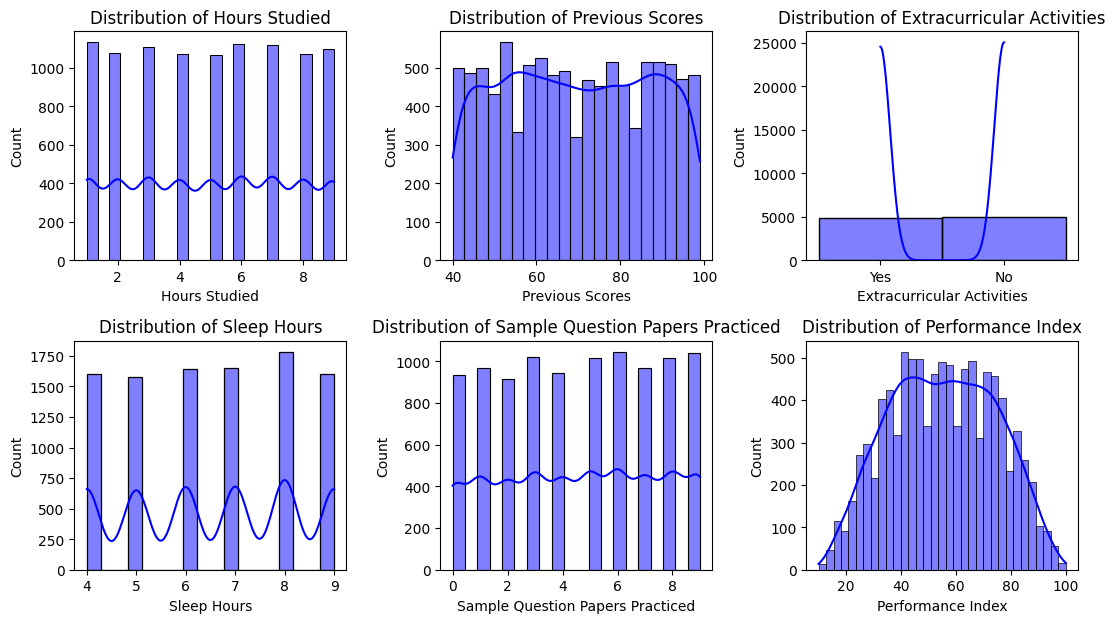

In [ ]:
histograms_ = df.drop('Extra Curricular Activities', axis=1, errors='ignore')

# Plotting distributions
plt.figure(figsize=(11,9))
for i, col in enumerate(histograms_.columns): # Iterate over column names
    plt.subplot(len(histograms_.columns) // 3 + 1, 3, i + 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

1. Students seem to study a wide range of hours, there is not any specific number of hours that stands out.

2. Previous scores are spread out across different ranges, but it looks like there are fewer students in the middle scores compared to the higher and lower ranges.

3. The number of students who do extracurricular activities and those who don’t is almost the same.

4. Sleep hours vary, but it seems like more students sleep around 7 or 8 hours compared to other amounts.

5. There is no particular common number of practiced sample question papers.

6. Most students performance scores fall in the middle range, with fewer students scoring very high or very low.


    there not seem to be outliers

In [ ]:
unique_values = df['Extracurricular Activities'].unique()
value_counts = df['Extracurricular Activities'].value_counts()

#  zip function to combine
zipped_result = list(zip(unique_values, value_counts))
print(zipped_result)

[('Yes', 4986), ('No', 4887)]


In [ ]:
print(((5052- 4948 )/(5052+ 4948 )) *100 ,"% percent is the how much difference between the count of students \n having and not having Extracurricular Activities")

1.04 % percent is the how much difference between the count of students 
 having and not having Extracurricular Activities


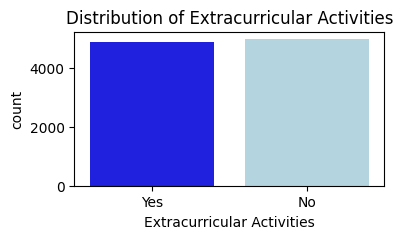

In [ ]:
# Bar plot (for showing distribution of a categorical feature)
plt.figure(figsize=(4,2))
sns.countplot(x='Extracurricular Activities', data=df, palette=['blue','lightblue'], hue='Extracurricular Activities')
plt.title('Distribution of Extracurricular Activities')
plt.show()


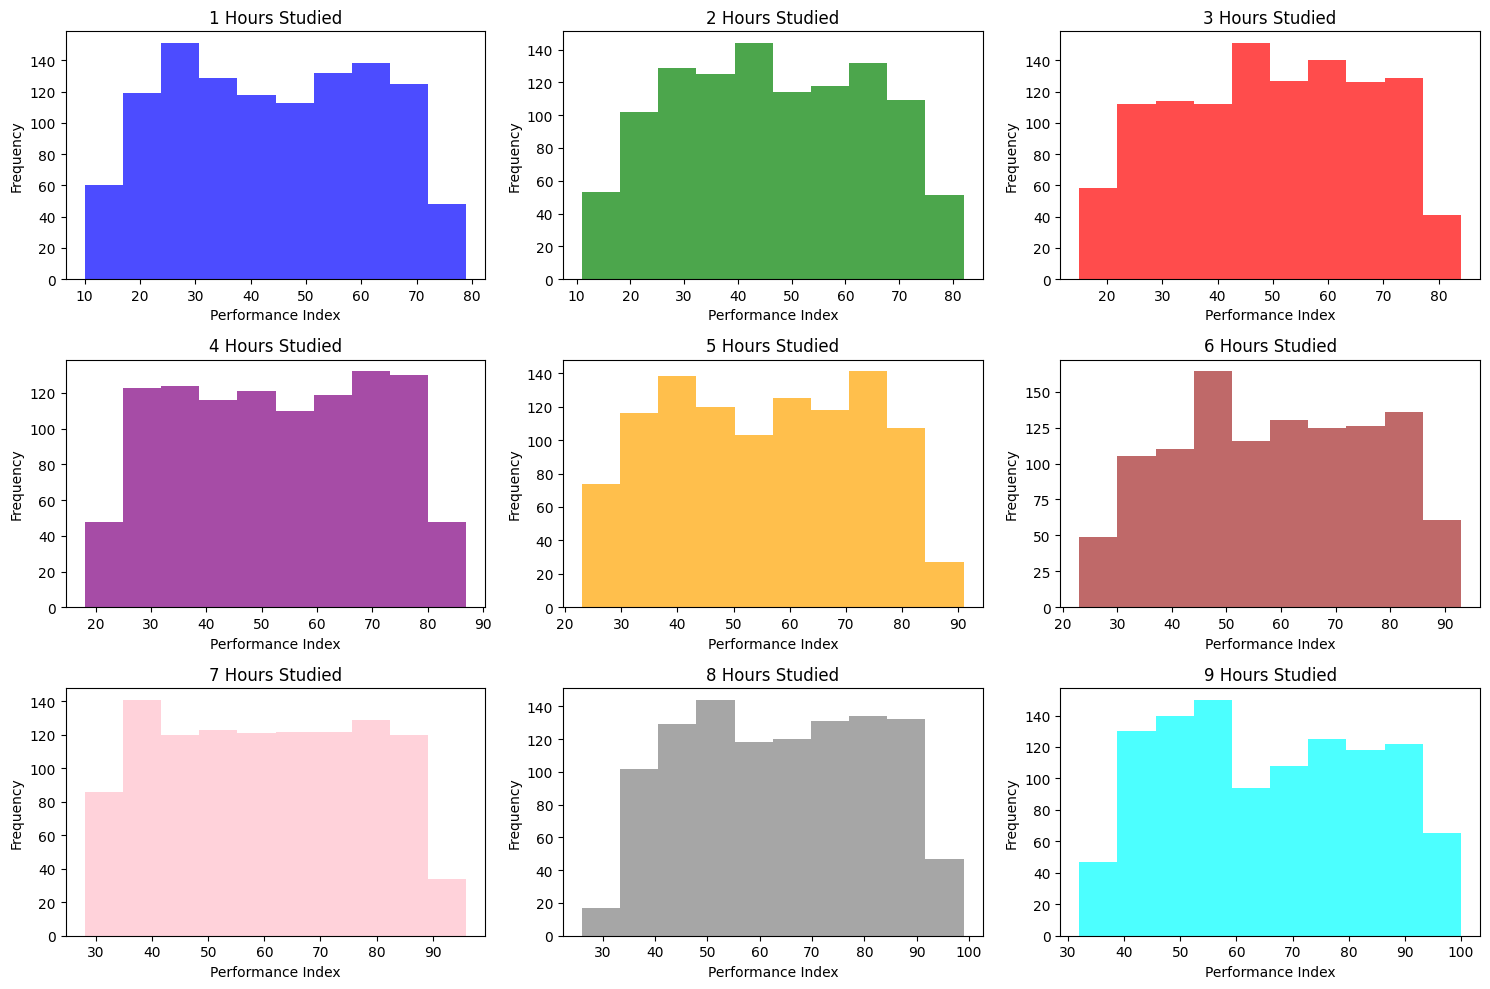

In [ ]:
#Distributions for students studying at different number of hours a day
# Create a 3x3 grid of subplots (3 plots per row, 9 plots in total)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))  # 3 rows, 3 columns

# List of hours studied from 1 to 9
hours_studied = range(1, 10)

# List of colors for each plot
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan']

# Loop through the subplots and hours to plot
for i, hours in enumerate(hours_studied):
    row = i // 3
    col = i % 3
    axes[row, col].hist(df[df['Hours Studied'] == hours]['Performance Index'], bins=10, color=colors[i], alpha=0.7)
    axes[row, col].set_title(f'{hours} Hours Studied')
    axes[row, col].set_xlabel('Performance Index')
    axes[row, col].set_ylabel('Frequency')

# Adjust layout to avoid overlapping titles/labels
plt.tight_layout()

# Show the plot
plt.show()

1. studying 1,2,3,4 hours does not get students to got a performance index higher than 90

2. there is students studying more than 4 hours and then getting a low performance index . imagine studying 9 hours then getting less than someone studied one hour ⁉ though  it is uncommon for someone studying  9 hours to have such a low performance index -> analyze factors that can affect the effectiveness of those study hours.


In [ ]:
# # Print "Performance Index" for those who study 9 hours
# # print(df[df['Hours Studied'] == 9]['Performance Index'])

# # Draw histograms with only borders for each "Hours Studied"
# df[df['Hours Studied'] == 9]['Performance Index'].hist(histtype='step', linewidth=2)
# df[df['Hours Studied'] == 8]['Performance Index'].hist(histtype='step', linewidth=2)
# df[df['Hours Studied'] == 7]['Performance Index'].hist(histtype='step', linewidth=2)
# df[df['Hours Studied'] == 6]['Performance Index'].hist(histtype='step', linewidth=2)
# df[df['Hours Studied'] == 5]['Performance Index'].hist(histtype='step', linewidth=2)
# df[df['Hours Studied'] == 4]['Performance Index'].hist(histtype='step', linewidth=2)
# df[df['Hours Studied'] == 3]['Performance Index'].hist(histtype='step', linewidth=2)
# df[df['Hours Studied'] == 2]['Performance Index'].hist(histtype='step', linewidth=2)
# df[df['Hours Studied'] == 1]['Performance Index'].hist(histtype='step', linewidth=2)

# # Show the plot
# plt.show()

Total students studying 9 hours are 1115

In [ ]:
#Analyze students that study 9 hours and their performance less than 40
# Filter the data for students who study 9 hours and have a performance index less than 40
low_performance_students = df[(df['Hours Studied'] == 9) & (df['Performance Index'] < 40)]

# Display the filtered data
low_performance_students.shape

(68, 6)

In [ ]:
#Analyze students that study 9 hours and their performance less than 40
# Filter the data for students who study 9 hours and have a performance index less than 40
high_performance_students = df[(df['Hours Studied'] == 9) & (df['Performance Index'] > 90)]

# Display the filtered data
high_performance_students.shape

(116, 6)

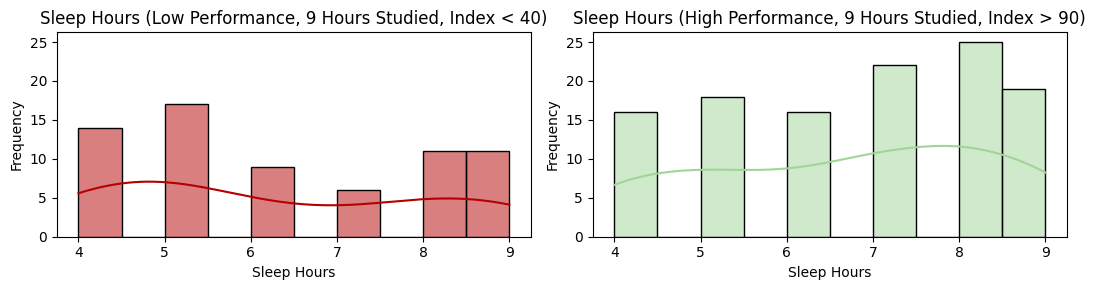

low_performance_students (68, 6)
high_performance_students (116, 6)


In [ ]:
# Filter for low and high performance students who study 9 hours
low_performance_students = df[(df['Hours Studied'] == 9) & (df['Performance Index'] < 40)]
high_performance_students = df[(df['Hours Studied'] == 9) & (df['Performance Index'] > 90)]

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(11,3))

# Plot histogram for Sleep Hours of low performance students
sns.histplot(low_performance_students['Sleep Hours'], bins=10, color='#b50000', ax=axes[0], kde=True)
axes[0].set_title('Sleep Hours (Low Performance, 9 Hours Studied, Index < 40)')
axes[0].set_xlabel('Sleep Hours')
axes[0].set_ylabel('Frequency')

# Plot histogram for Sleep Hours of high performance students
sns.histplot(high_performance_students['Sleep Hours'], bins=10, color='#a1d598', ax=axes[1], kde=True)
axes[1].set_title('Sleep Hours (High Performance, 9 Hours Studied, Index > 90)')
axes[1].set_xlabel('Sleep Hours')
axes[1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()

# Set the same y-axis limits for both histograms to allow  fair comparison
max_frequency = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, max_frequency)
axes[1].set_ylim(0, max_frequency)

# Show the plot
plt.show()
print("low_performance_students",low_performance_students.shape)
print("high_performance_students",high_performance_students.shape)


High-performance students are more evenly spread between different hours but have peaks at 7 and 8 hours, implying that sleeping more (closer to 8 hours) correlates with better performance.

The plots represent very small portion of data .so we can't get powerful insights from this analysis

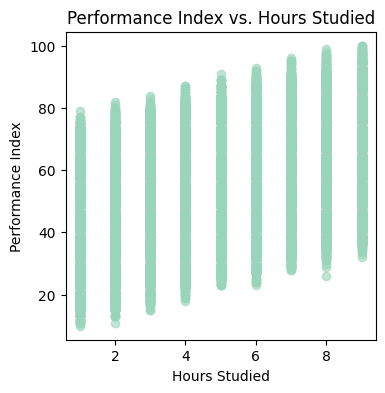

In [ ]:
# Scatter plot
plt.figure(figsize=(4,4))
plt.scatter(df['Hours Studied'], df['Performance Index'], alpha=0.6,c='#98d5ba')
plt.title('Performance Index vs. Hours Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.show()



# Correlation Analysis and Visualization

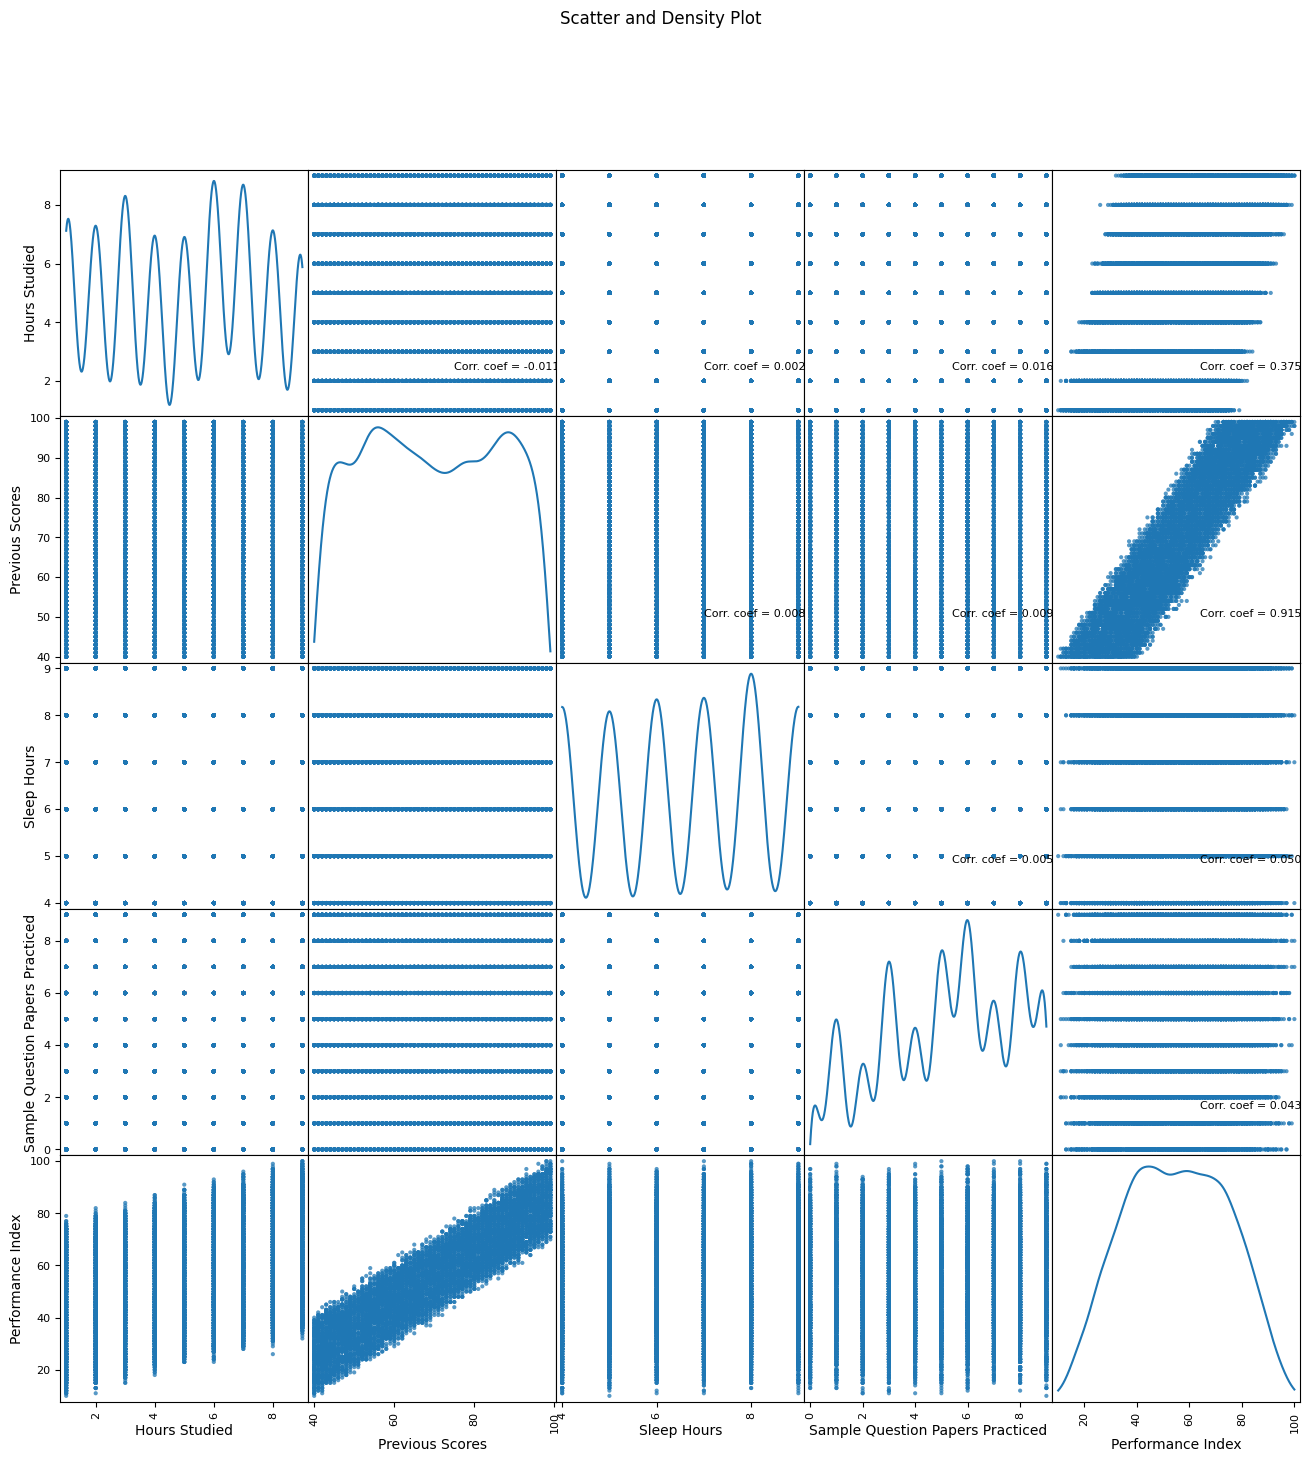

In [ ]:
"""https://www.kaggle.com/code/jlramirez/ciencias-de-datos-tarea-2"""
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df.dropna(axis='columns') #Corrected line, axis parameter should be set to 'columns'
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

plotScatterMatrix(df,16, 8)

1. Diagonal plots provide insights for the distribution of each feature.

2. Previous Scores have the highest correlation with Performance Index (0.91), and that means that students who performed well before tend to perform well again.
3. Hours Studied shows a moderate positive correlation with Performance Index (0.37); more study hours generally lead to better performance, but not as strongly as previous scores.
4.  practicing sample papers has a minor effect on performance.having a very weak positive correlation with Performance Index (0.04).
5. Sleep Hours show almost no correlation with Performance Index, meaning sleep patterns might not directly affect performance based on this data.
6. There is no meaningful correlation between Previous Scores and Hours Studied (0.01), showing that high previous scores don’t necessarily relate to more study hours now.
7. Sleep Hours and Hours Studied have no correlation (0.01), indicating no relationship between how much a student sleeps and how much they study.
8. Sample Question Papers Practiced does not correlate with Hours Studied or Previous Scores, as its correlation values are close to zero.
9. There’s a clear linear trend between Previous Scores and Performance Index, with higher previous scores generally leading to higher performance.
10. Hours Studied shows some positive trend with Performance Index, but there is noticeable variation, meaning studying more hours doesn’t always guarantee higher performance.
11. Features like Sleep Hours and Sample Question Papers Practiced show flat or noisy relationships with Performance Index, suggesting these factors might not be significant predictors of performance.
12. No two independent variables have high correlation with each other, indicating no significant multicollinearity between features.
13. The Performance Index follows a normal distribution, as observed from the diagonal density plot.

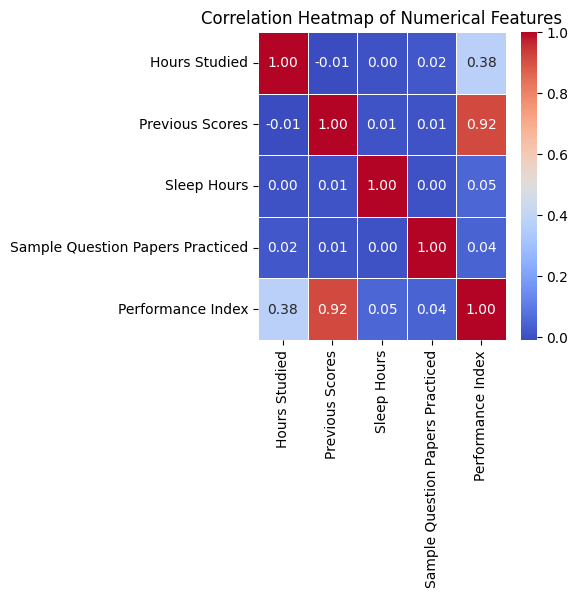

In [ ]:
# Correlation heatmap
plt.figure(figsize=(4,4))
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()  # Only include numerical columns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()



In [ ]:
numericFeaturesCorrelationWithTarget = df.drop(['Extracurricular Activities','Performance Index'], axis=1, errors='ignore')
correlation1 = numericFeaturesCorrelationWithTarget.corrwith(df['Performance Index']).sort_values(ascending=False) #Calculate correlation and sort
print(correlation1)

Previous Scores                     0.915135
Hours Studied                       0.375332
Sleep Hours                         0.050352
Sample Question Papers Practiced    0.043436
dtype: float64


In [ ]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

#Feature Engineering

In this section i repeat the correlation of the original dataframe to compare it with new dataframes engineered in different way to select the best columns for training

---



dff : a copy od the original dataframe df to keep the original the same

In [ ]:
dff =df.copy()

In [ ]:
dff.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0





**Applyning one hot encoding to the categorical feature . And because there is only 2 unique values that need to be encoded to 2 columns . keeping one column will be enough as they are the exact same but opposite 2 columns**

---





In [ ]:
#using sklearn

# Initialize the OneHotEncoder
encoder = OneHotEncoder(drop=None, sparse_output=False)

# Perform one-hot encoding
encoded_cols = encoder.fit_transform(dff[['Extracurricular Activities']])

# Convert the result to a DataFrame
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(['Extracurricular Activities']))

# Check if encoded_df has any NaNs
print(encoded_df.isnull().sum())

# Ensure the indices match
encoded_df.index = dff.index  # before this step i encounter missing values

# Concatenate the original DataFrame with the new encoded columns, and drop the original 'Extracurricular Activities' column
df_encoded = pd.concat([dff.drop('Extracurricular Activities', axis=1), encoded_df], axis=1)

# Check again for missing values after concatenation
print(df_encoded.isnull().sum())

# Display the first few rows of the new DataFrame
df_encoded.head()


Extracurricular Activities_No     0
Extracurricular Activities_Yes    0
dtype: int64
Hours Studied                       0
Previous Scores                     0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
Extracurricular Activities_No       0
Extracurricular Activities_Yes      0
dtype: int64


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_No,Extracurricular Activities_Yes
0,7,99,9,1,91,0.0,1.0
1,4,82,4,2,65,1.0,0.0
2,8,51,7,2,45,0.0,1.0
3,5,52,5,2,36,0.0,1.0
4,7,75,8,5,66,1.0,0.0


In [ ]:
df_encoded.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0
Extracurricular Activities_No,0
Extracurricular Activities_Yes,0


In [ ]:
#correlation of original features
print(df['Performance Index'].corr( df['Previous Scores']))
print(df['Performance Index'].corr( df['Hours Studied']))
print(df['Performance Index'].corr( df['Sleep Hours']))
print(df['Performance Index'].corr( df['Sample Question Papers Practiced']))


0.9151350792024562
0.3753320270787471
0.050352473917847376
0.0434357135254208


In [ ]:
# correlations of the dataset after one hot encoding the categorical feature
print(df_encoded['Performance Index'].corr( df_encoded['Previous Scores']))
print(df_encoded['Performance Index'].corr( df_encoded['Hours Studied']))
print(df_encoded['Performance Index'].corr( df_encoded['Sleep Hours']))
print(df_encoded['Performance Index'].corr( df_encoded['Sample Question Papers Practiced']))
print(df_encoded['Performance Index'].corr( df_encoded['Extracurricular Activities_No']))
print(df_encoded['Performance Index'].corr( df_encoded['Extracurricular Activities_Yes']))

0.9151350792024562
0.3753320270787471
0.050352473917847376
0.0434357135254208
-0.026074591573450705
0.02607459157345072


(-0.026074591573450705,  0.02607459157345072)


---


same correlations one negative and one positive . they represent the same thing so i will drop one of them

In [ ]:
df_encoded.drop(['Extracurricular Activities_No'], axis=1, errors='ignore',inplace=True)

In [ ]:
print(df_encoded['Performance Index'].corr( df_encoded['Previous Scores']))
print(df_encoded['Performance Index'].corr( df_encoded['Hours Studied']))
print(df_encoded['Performance Index'].corr( df_encoded['Sleep Hours']))
print(df_encoded['Performance Index'].corr( df_encoded['Sample Question Papers Practiced']))
print(df_encoded['Performance Index'].corr( df_encoded['Extracurricular Activities_Yes']))

0.9151350792024562
0.3753320270787471
0.050352473917847376
0.0434357135254208
0.02607459157345072


Combine 'Hours Studied' and 'Previous Scores' as they are both have positive correlation with the target "Performance Index" in a new column 'Study_Score_Interaction'

In [ ]:
#df_enhanced: Implies that the DataFrame has been enhanced with new features Study_Score_Interaction from
#multiplying ['Hours Studied'] with ['Previous Scores'].

df_enhanced = df_encoded.copy() # Create a copy of the DataFrame
df_enhanced['Study_Score_Interaction'] = df_encoded['Hours Studied'] * df_encoded['Previous Scores']

# drop 'Hours Studied' and 'Previous Scores' from df_enhanced
df_enhanced.drop(['Hours Studied', 'Previous Scores'], axis=1, inplace=True)
df_enhanced.head(0)

,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes,Study_Score_Interaction


In [ ]:
print(df_enhanced['Performance Index'].corr( df_enhanced['Sleep Hours']))
print(df_enhanced['Performance Index'].corr( df_enhanced['Sample Question Papers Practiced']))
print(df_enhanced['Performance Index'].corr( df_enhanced['Extracurricular Activities_Yes']))
print(df_enhanced['Performance Index'].corr( df_enhanced['Study_Score_Interaction']))

0.050352473917847376
0.0434357135254208
0.02607459157345072
0.7207351852389163


**`we lost the highest correlation of the previous score column with 0.91513 so we will step back 1 step `**

---



In [ ]:
df_enhanced.isnull().sum()

,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0
Extracurricular Activities_Yes,0
Study_Score_Interaction,0


In [ ]:
#df_enhanced2: Implies that the DataFrame has been enhanced with new features Study_Score_Interaction from
#multiplying ['Hours Studied'] with ['Previous Scores'].

df_enhanced2 = df_encoded.copy() # Create a copy of the DataFrame
df_enhanced2['Practice_and_sleep'] = df_encoded['Sleep Hours'] * df_encoded['Sample Question Papers Practiced']

# drop 'Hours Studied' and 'Previous Scores' from df_enhanced
df_enhanced2.drop(['Sleep Hours', 'Sample Question Papers Practiced'], axis=1, inplace=True)
df_enhanced2.head(0)

,Hours Studied,Previous Scores,Performance Index,Extracurricular Activities_Yes,Practice_and_sleep


In [ ]:
print(df_enhanced2['Performance Index'].corr( df_enhanced2['Previous Scores']))
print(df_enhanced2['Performance Index'].corr( df_enhanced2['Hours Studied']))
print(df_enhanced2['Performance Index'].corr( df_enhanced2['Extracurricular Activities_Yes']))
print(df_enhanced2['Performance Index'].corr( df_enhanced2['Practice_and_sleep']))

0.9151350792024562
0.3753320270787471
0.02607459157345072
0.055009131747979764


`combining the features 'Sleep Hours', 'Sample Question Papers Practiced' bring us with a correlation not slight high from the original . still higher a very little`

binary feature does not interact meaningfully with other features, so i will not try to feature engineer it bec it maybe add redundancy to your model.?

In [ ]:
df_enhanced2.columns

Index(['Hours Studied', 'Previous Scores', 'Performance Index',
       'Extracurricular Activities_Yes', 'Practice_and_sleep'],
      dtype='object')

In [ ]:
df_enhanced2.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Performance Index,0
Extracurricular Activities_Yes,0
Practice_and_sleep,0


`df_enhanced3 : a dataset with the best correlated features with the target .like df_enhaced i multiplied 'Hours Studied', 'Previous Scores' but because they already give good correlation i kept them instead of dropping them like in df_enhaced.`


---



`df_enhanced3 have the feature Practice_and_sleep that is the result of multiplying 'Sleep Hours', 'Sample Question Papers Practiced' and these columns got dropped here exactly like df_enhaced2`

In [ ]:
df_enhanced3=df_encoded.copy()
df_enhanced3['Practice_and_sleep'] = df_encoded['Sleep Hours'] * df_encoded['Sample Question Papers Practiced']
df_enhanced3['Study_Score_Interaction'] = df_encoded['Hours Studied'] * df_encoded['Previous Scores']

df_enhanced3.drop(['Sleep Hours', 'Sample Question Papers Practiced'], axis=1, inplace=True)
df_enhanced3.head()

,Hours Studied,Previous Scores,Performance Index,Extracurricular Activities_Yes,Practice_and_sleep,Study_Score_Interaction
0,7,99,91,1.0,9,693
1,4,82,65,0.0,8,328
2,8,51,45,1.0,14,408
3,5,52,36,1.0,10,260
4,7,75,66,0.0,40,525


In [ ]:
# df_enhanced3 correlations with the target
print(df_enhanced3['Performance Index'].corr( df_enhanced3['Previous Scores']))
print(df_enhanced3['Performance Index'].corr( df_enhanced3['Hours Studied']))
print(df_enhanced3['Performance Index'].corr( df_enhanced3['Extracurricular Activities_Yes']))
print(df_enhanced3['Performance Index'].corr( df_enhanced3['Practice_and_sleep']))
print(df_enhanced3['Performance Index'].corr( df_enhanced3['Study_Score_Interaction']))



0.9151350792024562
0.3753320270787471
0.02607459157345072
0.055009131747979764
0.7207351852389163


***`df_enhanced3 is the selected dataframe to enter the modeling phaze`***

---



# Modeling

## Splitting data



*   For modeling i used Linear Regression , Desicion Tree , Random Forest
*   There is no need for scaling when using  Desicion Tree , Random Forest
*   I evaluate Linear Regression before and after scaling . the error i got was the same


*   Linear regression section have its own splitting and scaling






In [ ]:

# Now proceed with your splitting
X = df_enhanced3.drop('Performance Index', axis=1)
y = df_enhanced3['Performance Index']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the resulting splits
print("Training feature set shape:", X_train.shape)
print("Testing feature set shape:", X_test.shape)
print("Training target set shape:", y_train.shape)
print("Testing target set shape:", y_test.shape)

Training feature set shape: (7898, 5)
Testing feature set shape: (1975, 5)
Training target set shape: (7898,)
Testing target set shape: (1975,)


In [ ]:
# Check for NaN values in X_train
print(X_train.isna().sum())

# Check for NaN values in y_train
print(y_train.isna().sum())


Hours Studied                     0
Previous Scores                   0
Extracurricular Activities_Yes    0
Practice_and_sleep                0
Study_Score_Interaction           0
dtype: int64
0


## Linear Regression

In [ ]:
# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model
model.fit(X_train, y_train)

# Predict on the testing set
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.7067775345044611


linear regression after scaling

In [ ]:
df_enhanced4=df_enhanced3.copy()

In [ ]:
df_enhanced4.columns

Index(['Hours Studied', 'Previous Scores', 'Performance Index',
       'Extracurricular Activities_Yes', 'Practice_and_sleep',
       'Study_Score_Interaction'],
      dtype='object')

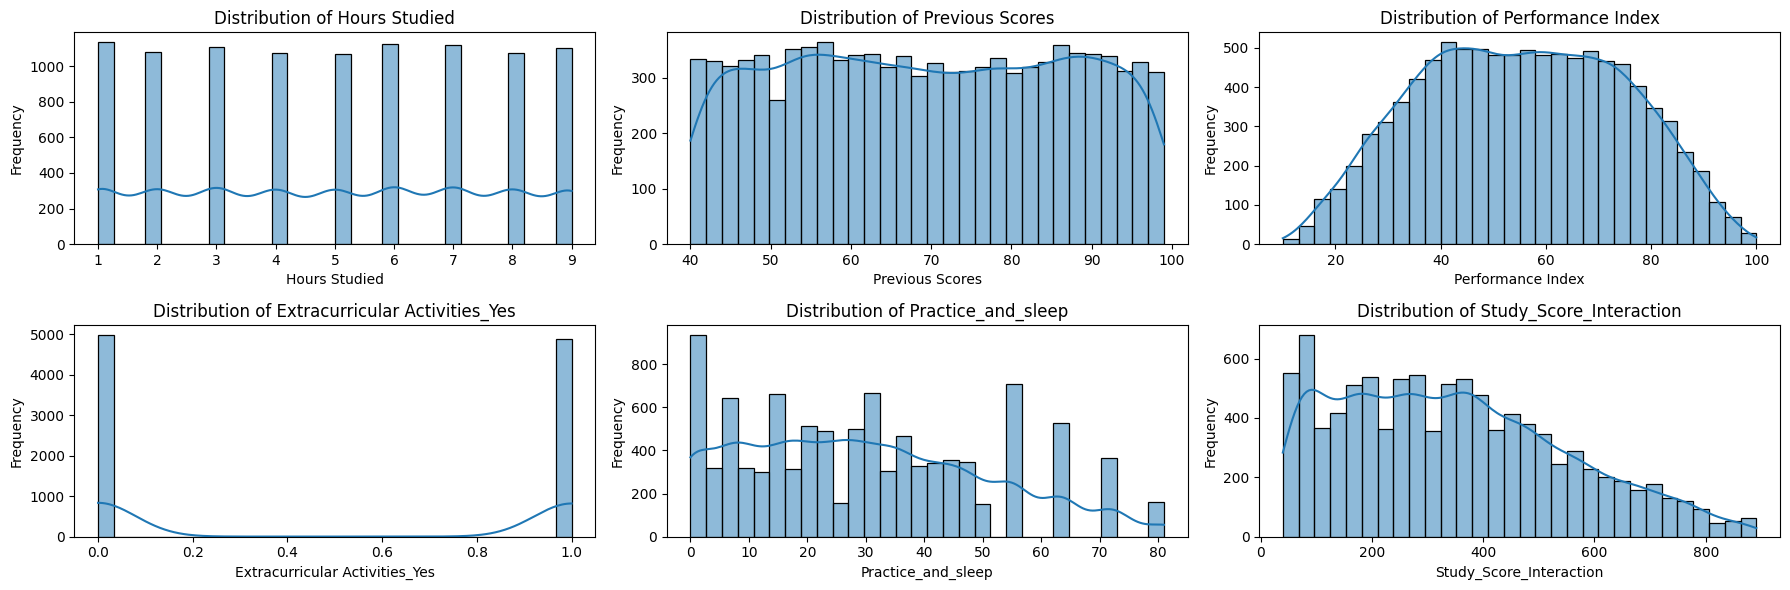

In [ ]:
# Determine the number of rows needed for subplots
num_columns = len(df_enhanced4.columns)
num_rows = (num_columns + 2) // 3  # Add two to handle any remainder if num_columns is not a multiple of 3

# Set up the figure and axes for the subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(18, 6 ))  # Width is 18 (6 per subplot) and height is dynamically adjusted

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Loop through the columns and plot
for i, column in enumerate(df_enhanced4.columns):
    sns.histplot(df_enhanced4[column], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# Turn off any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
Xx_train, Xx_test, yy_train, yy_test = train_test_split(df_enhanced4.drop('Performance Index', axis=1), df_enhanced4['Performance Index'], test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data
scaler.fit(Xx_train)

# Transform the training data
X_train_scaled = scaler.transform(Xx_train)

# Transform the testing data
X_test_scaled = scaler.transform(Xx_test)

In [ ]:
lin_reg=LinearRegression()
lin_reg.fit(X_train_scaled, yy_train)

LinearRegression()

In [ ]:
yy_pred =lin_reg.predict(X_test_scaled)
yy_pred

array([46.92153109, 81.15850348, 61.07140834, ..., 76.25190552,
       86.4443423 , 35.4663695 ])

In [ ]:
yy_test[:5]  # actual testing values

,Performance Index
6099,47
106,76
9265,62
4707,23
2155,76


In [ ]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(yy_test, yy_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.7067775345044607


## Desicion Tree

In [ ]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(X_train , y_train)

DecisionTreeRegressor()

In [ ]:
# Predict on the test set
y_pred = tree_reg.predict(X_test)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Print the MAE
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.4486075949367088


In [ ]:

# Predict on the test set
y_pred2 = tree_reg.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred2)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Print the RMSE
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 3.0928357394779966


##Random Forest

In [ ]:
# Initialize the Random Forest Regressor
forest_reg = RandomForestRegressor()

# Fit the model on the training data
forest_reg.fit(X_train, y_train)

# Predict on the test set
y_pred_forest = forest_reg.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse_forest = mean_squared_error(y_test, y_pred_forest)

# Calculate Root Mean Squared Error (RMSE)
rmse_forest = np.sqrt(mse_forest)

# Calculate Mean Absolute Error (MAE)
mae_forest = mean_absolute_error(y_test, y_pred_forest)

print("Mean Absolute Error (MAE) for Random Forest:", mae_forest)
print("Root Mean Squared Error (RMSE) for Random Forest:", rmse_forest)

Mean Absolute Error (MAE) for Random Forest: 1.9680320152702429
Root Mean Squared Error (RMSE) for Random Forest: 2.466826910135453


`MAE LR =  1.7067775345044607`

`MAE DT = 2.451054852320675`

`MAE RF = 1.9645796814437324`


***THE LEAST ERROR EVALUATED WAS BY LINEAR REGRESSION***